## Aplicando modelos, escolhendo um e treinando a base

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import (
    MinMaxScaler,
    PowerTransformer,
    RobustScaler,
)

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from xgboost import plot_importance

from sklearn.neighbors import KNeighborsClassifier

from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance

from Apoio.auxiliares import dataframe_coeficientes
from Apoio.config import DADOS_TRATADOS
from Apoio.graficos import plot_comparar_metricas_modelos, plot_coeficientes
from Apoio.models import RANDOM_STATE
from Apoio.models import (
    grid_search_cv_classificador,
    treinar_e_validar_modelo_classificacao,
    organiza_resultados,
)

sns.set_theme(palette="bright")

In [2]:
df = pd.read_parquet(DADOS_TRATADOS)

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V19,V20,V21,V23,V24,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.403993,0.251412,-0.018307,-0.110474,0.066928,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.145783,-0.069083,-0.225775,0.101288,-0.339846,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-1.232622,-0.208038,-0.108300,-0.190321,-1.175575,-0.221929,0.062723,0.061458,123.50,0
3,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.803487,0.408542,-0.009431,-0.137458,0.141267,0.502292,0.219422,0.215153,69.99,0
4,2.0,-0.425966,0.960523,1.141109,-0.168252,0.420987,-0.029728,0.476201,0.260314,-0.568671,...,-0.033194,0.084968,-0.208254,-0.026398,-0.371427,0.105915,0.253844,0.081080,3.67,0


In [3]:
coluna_min_max = ["Time"]

coluna_power_transformer = ["Amount"]

coluna_target = ["Class"]

coluna_robust_scaler = [
    coluna for coluna in df.columns
    if coluna not in (coluna_min_max + coluna_power_transformer + coluna_target)
]

In [4]:
coluna_robust_scaler

['V1',
 'V2',
 'V3',
 'V4',
 'V5',
 'V6',
 'V7',
 'V8',
 'V9',
 'V10',
 'V11',
 'V12',
 'V14',
 'V16',
 'V17',
 'V18',
 'V19',
 'V20',
 'V21',
 'V23',
 'V24',
 'V26',
 'V27',
 'V28']

In [5]:
X = df.drop(columns=coluna_target)
y = df[coluna_target].values.ravel()

In [6]:
preprocessamento = ColumnTransformer(
    transformers = [
        ("min_max", MinMaxScaler(), coluna_min_max),
        ("robust", RobustScaler(), coluna_robust_scaler),
        ("power_transform", PowerTransformer(), coluna_power_transformer)
    ]
)

In [7]:
scale_pos_weight = np.bincount(y)[0] / np.bincount(y)[1]
scale_pos_weight

np.float64(520.5040650406504)

In [8]:
classificadores = {
    "DummyClassifier": {
        "preprocessor": None,
        "classificador": DummyClassifier(strategy="stratified")
    },

    "LogisticRegression": {
        "preprocessor": preprocessamento,
        "classificador": LogisticRegression(class_weight="balanced")
    },

    "DecisionTreeClassifier": {
       "preprocessor": None,
        "classificador": DecisionTreeClassifier(class_weight="balanced")
    },

    "LGBMClassifier": {
       "preprocessor": None,
        "classificador": LGBMClassifier(random_state=RANDOM_STATE, n_jobs=-1, verbose=-1, scale_pos_weight=scale_pos_weight)
    },

    "XGBClassifier": {
       "preprocessor": None,
        "classificador": XGBClassifier(random_state=RANDOM_STATE, n_jobs=-1, scale_pos_weight=scale_pos_weight)
    },

    "KNeighborsClassifier": {
       "preprocessor": preprocessamento,
        "classificador": KNeighborsClassifier()
    }
}

In [9]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

In [10]:
resultados = {
    nome_modelo: treinar_e_validar_modelo_classificacao(X, y, kf, **classificador)
    for nome_modelo, classificador in classificadores.items()
}

df_resultados = organiza_resultados(resultados)
df_resultados

,model,fit_time,score_time,test_accuracy,test_balanced_accuracy,test_f1,test_precision,test_recall,test_roc_auc,test_average_precision,time_seconds
0,DummyClassifier,0.09534,0.088575,0.996375,0.499141,0.0,0.0,0.0,0.498829,0.00191,0.183914
1,DummyClassifier,0.098222,0.068527,0.995888,0.498897,0.0,0.0,0.0,0.498897,0.00191,0.166749
2,DummyClassifier,0.089397,0.068141,0.996025,0.498965,0.0,0.0,0.0,0.498916,0.00191,0.157538
3,DummyClassifier,0.088348,0.051037,0.996414,0.49917,0.0,0.0,0.0,0.499053,0.001929,0.139385
4,DummyClassifier,0.081748,0.055482,0.996181,0.499053,0.0,0.0,0.0,0.499034,0.001929,0.13723
5,LogisticRegression,3.734544,0.205641,0.98328,0.935609,0.168605,0.093148,0.887755,0.985234,0.608503,3.940184
6,LogisticRegression,3.384981,0.215493,0.977785,0.958317,0.138973,0.075041,0.938776,0.987455,0.731336,3.600474
7,LogisticRegression,2.783149,0.207386,0.978545,0.958698,0.143191,0.077506,0.938776,0.978128,0.800227,2.990535
8,LogisticRegression,2.870645,0.201446,0.981292,0.940221,0.156415,0.085659,0.89899,0.97971,0.687418,3.07209
9,LogisticRegression,2.658715,0.205503,0.978252,0.95382,0.141538,0.076603,0.929293,0.981516,0.738762,2.864218


In [11]:
df_resultados.groupby("model").mean().sort_values("test_average_precision")

,fit_time,score_time,test_accuracy,test_balanced_accuracy,test_f1,test_precision,test_recall,test_roc_auc,test_average_precision,time_seconds
model,,,,,,,,,,
DummyClassifier,0.090611,0.066352,0.996177,0.499045,0.0,0.0,0.0,0.498946,0.001918,0.156963
LGBMClassifier,2.140024,0.214521,0.921144,0.890573,0.050796,0.026463,0.859885,0.884299,0.023549,2.354545
DecisionTreeClassifier,18.581527,0.082274,0.99915,0.874789,0.771861,0.795736,0.749948,0.874789,0.597109,18.663801
LogisticRegression,3.086407,0.207094,0.979831,0.949333,0.149744,0.081591,0.918718,0.982408,0.713249,3.2935
KNeighborsClassifier,1.25252,87.58056,0.999462,0.882054,0.844453,0.945503,0.764193,0.928754,0.818819,88.833079
XGBClassifier,2.797455,0.253443,0.999622,0.923736,0.895317,0.949773,0.847557,0.986293,0.889975,3.050897


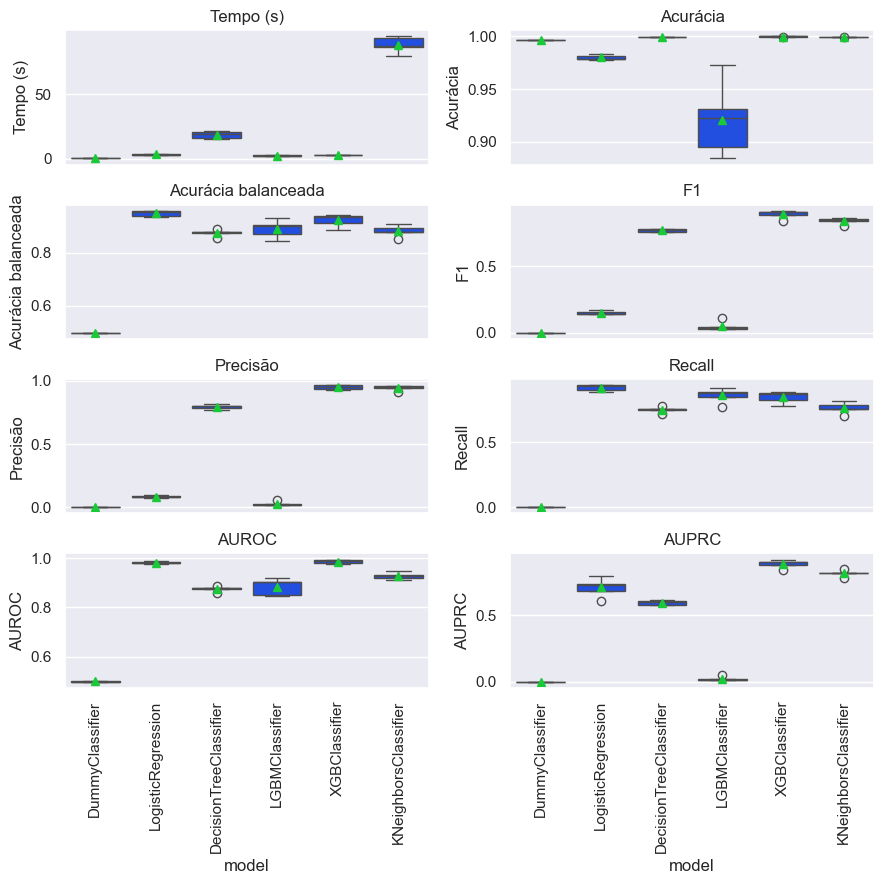

In [12]:
plot_comparar_metricas_modelos(df_resultados)

- faça o groupby no dataframe anterior, usando "model", a média e os valores ordenados pelo test average precision
- use a função de plot_comparar_metricas_modelos
- verifique os classificadores do melhor modelo
- use a função treinar_e_validar_modelo_classificacao com o modelo escolhido
- separe treino e teste com o stratify y, crie o clf e treine ele com os treinos, use o permutation_importance, use o perm_imp.importances_mean.argsort para definir uma ordem, depois crie um boxplot
- verifique as colunas com perm_imp.importances_mean menor que 0.01 e exclua elas
- use a função de treinar e validar modelo novamente
- defina a grade de parâmetros
- defina um clf com o modelo escolhido
- use a função do grid_search_cv_classificador
- treine o grid_search
- verifique o best_params_, best_score_, best_estimator_
- crie uma lista comas mean_ para cada coluna no novo dataframe se o .startswith("test"), depois printe o cv_results_ de cada coluna com o best_index_ para cada coluna criada anteriormente
- plot um gráfico com o plot_importance com o best_estimator_, usando o weight como importance_type, depois repita isso, mas com o gain
